<a href="https://colab.research.google.com/github/raina1234-a/Reddit-Post-Analysis-and-Moderation-Classifier/blob/main/reddit_postClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/r_dataisbeautiful_posts.csv")

/tmp/ipykernel_2022/3835883297.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/r_dataisbeautiful_posts.csv")


In [ ]:
df.columns

Index(['id', 'title', 'score', 'author', 'author_flair_text', 'removed_by',
       'total_awards_received', 'awarders', 'created_utc', 'full_link',
       'num_comments', 'over_18'],
      dtype='object')

In [ ]:
df.shape

(193091, 12)

In [ ]:
df.describe()

,score,total_awards_received,created_utc,num_comments
count,193091.000000,53239.000000,1.930910e+05,193091.000000
mean,180.261157,0.005898,1.501766e+09,26.374502
std,1946.307188,0.241624,6.569719e+07,206.886930
min,0.000000,0.000000,1.329263e+09,0.000000
25%,1.000000,0.000000,1.449986e+09,1.000000
50%,1.000000,0.000000,1.502211e+09,1.000000
75%,4.000000,0.000000,1.561930e+09,4.000000
max,116226.000000,30.000000,1.600174e+09,18801.000000


In [ ]:
df.isna().sum()

,0
id,0
title,1
score,0
author,0
author_flair_text,166218
removed_by,177406
total_awards_received,139852
awarders,150523
created_utc,0
full_link,0


In [ ]:
df.dropna(subset=['title'],inplace=True)

In [ ]:
df.drop(["author_flair_text","created_utc","awarders"],axis=1,inplace=True)

In [ ]:
df.removed_by.value_counts()

,count
removed_by,
moderator,11036
deleted,2398
automod_filtered,1187
reddit,1063
author,1


In [ ]:
df.removed_by.notnull().sum()

np.int64(15685)

In [ ]:
df.over_18.value_counts()

,count
over_18,
False,192093
True,997


In [ ]:
df.total_awards_received.fillna(0,inplace=True)

/tmp/ipykernel_2022/976138776.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.total_awards_received.fillna(0,inplace=True)


In [ ]:
df.fillna("NOT DELETED",inplace=True)

In [ ]:
df

,id,title,score,author,removed_by,total_awards_received,full_link,num_comments,over_18
0,it7yz2,[OC] The World’s Forests Mapped,1,vividmaps,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
1,it7uig,[OC] Airbnb presence mapped in Barcelona (BCN)...,1,JonnieNeptune,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
2,it7t4z,A marketplace for open streaming data sources,1,DangerMouse289,automod_filtered,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
3,it7jfq,[OC] Black Owner-Occupied Housing,1,SocialExplorerInc,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
4,it7a3r,[OC] My monthly average steps in 2020. Quarant...,1,ahmedgelemli,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
...,...,...,...,...,...,...,...,...,...
193086,pqbdl,Infosthetics seems like it belongs here.,15,magiclamp,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
193087,pqav2,Time lapse of every nuclear detonation from 19...,9,th3sousa,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
193088,pq922,Wavii.,13,ddshroom,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,2,False
193089,ppx09,An interactive representation of Pres. Obamas ...,21,zanycaswell,NOT DELETED,0.0,https://www.reddit.com/r/dataisbeautiful/comme...,0,False


In [ ]:
df.groupby("author").sum()["total_awards_received"].sort_values(ascending=False)

,total_awards_received
author,
PieChartPirate,30.0
Spooderman89,27.0
asherfergusson,18.0
_The_Mattmatician,14.0
Janman14,12.0
...,...
Spickbug,0.0
SpiceEyes,0.0
SphinxP,0.0


In [ ]:
df["num_comments"] = pd.to_numeric(df["num_comments"], errors="coerce")
df.groupby("author")["num_comments"].sum().sort_values(ascending=False)


,num_comments
author,
[deleted],137201
rhiever,69063
BoMcCready,58685
jimrosenz,50146
theimpossiblesalad,49865
...,...
raufanmingcit,0
ratytedi,0
rattleio,0


In [ ]:
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df.groupby("author").sum()["score"].sort_values(ascending=False)

,score
author,
[deleted],573563
neilrkaye,450520
datashown,444349
chartr,433525
Geographist,384489
...,...
thejestercrown,0
thelolrus,0
Molteniron,0


In [ ]:
df["over_18"] = pd.to_numeric(df["over_18"], errors="coerce")
df.groupby("author").sum()["over_18"].sort_values(ascending=False)

,over_18
author,
[deleted],187
indianescorts0,7
angelrumio,5
FrigidShadow,5
licensecrack,5
...,...
SquareBottle,0
Squageheimer,0
SqojoSmiley,0


In [ ]:
df.groupby(["over_18","removed_by"]).count()

id   title   score  author  \
over_18 removed_by                                         
False   NOT DELETED       176498  176498  176498  176498   
        author                 1       1       1       1   
        automod_filtered    1181    1181    1181    1181   
        deleted             2385    2385    2385    2385   
        moderator          10977   10977   10977   10977   
        reddit              1051    1051    1051    1051   
True    NOT DELETED          907     907     907     907   
        automod_filtered       6       6       6       6   
        deleted               13      13      13      13   
        moderator             59      59      59      59   
        reddit                12      12      12      12   

                          total_awards_received  full_link  num_comments  
over_18 removed_by                                                        
False   NOT DELETED                      176498     176498        176498  
        author                                1          1             1  
        automod_filtered                   1181       1181          1181  
        deleted                            2385       2385          2385  
        moderator                         10977      10977         10977  
        reddit                             1051       1051          1051  
True    NOT DELETED                         907        907           907  
        automod_filtered                      6          6             6  
        deleted                              13         13            13  
        moderator                            59         59            59  
        reddit                               12         12            12

In [ ]:
df.corr(numeric_only=True)

,score,total_awards_received,num_comments,over_18
score,1.000000,0.156223,0.597279,0.018457
total_awards_received,0.156223,1.000000,0.168735,0.005340
num_comments,0.597279,0.168735,1.000000,0.028543
over_18,0.018457,0.005340,0.028543,1.000000


In [ ]:
df["adult_18"] = 0
df["adult_18"] = df["over_18"].apply(lambda row: 0 if row==False else 1)

In [ ]:
df["adult_18"].value_counts()

,count
adult_18,
0,192093
1,997


In [ ]:
df["adult_18"] = 0
df.loc[df["removed_by"] != "NOT DELETED", "adult_18"] = 1

df["adult_18"].value_counts()

,count
adult_18,
0,177405
1,15685


In [ ]:
import nltk
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

def preprocess_text(text):
    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in string.punctuation]

    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    stemmer = PorterStemmer()
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]

    return ' '.join(stemmed_tokens)

In [ ]:
df["clean_title"] = df["title"].apply(preprocess_text)

In [ ]:
df["deleted"] = 0

df.loc[df["removed_by"] != "NOT DELETED", "deleted"] = 1

df["deleted"].value_counts()

,count
deleted,
0,177405
1,15685


In [ ]:
df["deleted"].value_counts(normalize=True)

,proportion
deleted,
0,0.918768
1,0.081232


In [ ]:
df["deleted"].value_counts(normalize=True)

,proportion
deleted,
0,0.918768
1,0.081232


In [ ]:
X = df["clean_title"]
y = df["deleted"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [ ]:
y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8343259619866383
Precision: 0.2778912954638333
Recall: 0.6503028371055148
F1 Score: 0.38938728765031494

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90     35481
           1       0.28      0.65      0.39      3137

    accuracy                           0.83     38618
   macro avg       0.62      0.75      0.65     38618
weighted avg       0.91      0.83      0.86     38618



In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Confusion Matrix:
[[30180  5301]
 [ 1097  2040]]


In [ ]:
X_train_tfidf
X_test_tfidf
y_train
y_test

,deleted
22261,0
41324,0
109734,0
104539,0
51571,0
...,...
107022,0
103778,0
52353,0
12459,1


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8416541509140815
Precision: 0.2760902255639098
Recall: 0.5852725533949633
F1 Score: 0.3751915806682334

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91     35481
           1       0.28      0.59      0.38      3137

    accuracy                           0.84     38618
   macro avg       0.62      0.72      0.64     38618
weighted avg       0.90      0.84      0.87     38618


Confusion Matrix:
[[30667  4814]
 [ 1301  1836]]


In [ ]:
metadata = df[
    [
        "score",
        "num_comments",
        "total_awards_received",
        "over_18"
    ]
].copy()
metadata.head()

,score,num_comments,total_awards_received,over_18
0,1,1,0.0,False
1,1,0,0.0,False
2,1,0,0.0,False
3,1,1,0.0,False
4,1,0,0.0,False


In [ ]:
metadata["score"] = pd.to_numeric(
    metadata["score"],
    errors="coerce"
)

metadata["num_comments"] = pd.to_numeric(
    metadata["num_comments"],
    errors="coerce"
)

metadata["total_awards_received"] = pd.to_numeric(
    metadata["total_awards_received"],
    errors="coerce"
)

metadata["over_18"] = pd.to_numeric(
    metadata["over_18"],
    errors="coerce"
)

In [ ]:
metadata.isnull().sum()

,0
score,0
num_comments,0
total_awards_received,0
over_18,0


In [ ]:
X_meta_train = metadata.loc[X_train.index]
X_meta_test = metadata.loc[X_test.index]

print(X_meta_train.shape)
print(X_meta_test.shape)

(154472, 4)
(38618, 4)


In [ ]:
from xgboost import XGBClassifier
scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 11.310487727127828


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_meta_train,
    y_train
)

y_pred_xgb = xgb_model.predict(X_meta_test)

y_prob_xgb = xgb_model.predict_proba(X_meta_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7377647729038272
Precision: 0.19907008782503874
Recall: 0.7370098820529168
F1 Score: 0.3134702732018168

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     35481
           1       0.20      0.74      0.31      3137

    accuracy                           0.74     38618
   macro avg       0.58      0.74      0.58     38618
weighted avg       0.91      0.74      0.80     38618


Confusion Matrix:
[[26179  9302]
 [  825  2312]]


In [ ]:
df["over_18"].value_counts()

,count
over_18,
False,192093
True,997


In [ ]:
df["over_18"].value_counts(normalize=True)

,proportion
over_18,
False,0.994837
True,0.005163


In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_meta_train.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
0,score,0.561387
1,num_comments,0.365317
2,total_awards_received,0.058398
3,over_18,0.014898


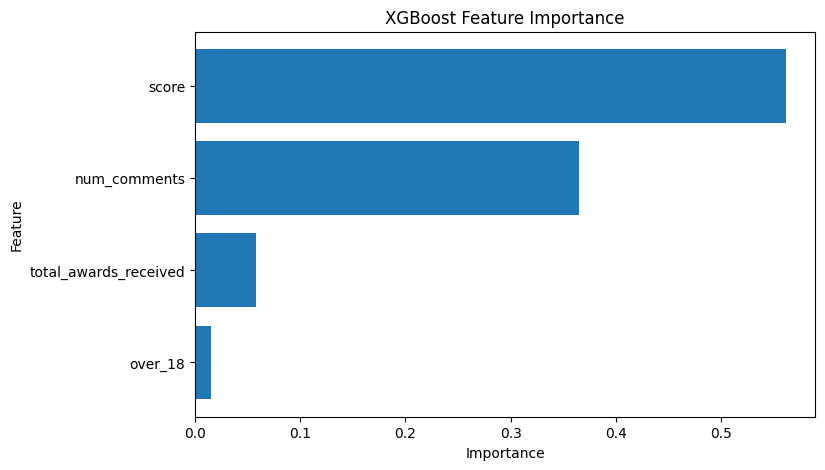

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
print("TF-IDF train:", X_train_tfidf.shape)
print("TF-IDF test:", X_test_tfidf.shape)

print("Metadata train:", X_meta_train.shape)
print("Metadata test:", X_meta_test.shape)

TF-IDF train: (154472, 50000)
TF-IDF test: (38618, 50000)
Metadata train: (154472, 4)
Metadata test: (38618, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_test_scaled = scaler.transform(X_meta_test)

In [ ]:
from scipy.sparse import hstack, csr_matrix

X_train_combined = hstack([
    X_train_tfidf,
    csr_matrix(X_meta_train_scaled)
])

X_test_combined = hstack([
    X_test_tfidf,
    csr_matrix(X_meta_test_scaled)
])

print(X_train_combined.shape)
print(X_test_combined.shape)

(154472, 50004)
(38618, 50004)


In [ ]:
svm_combined = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_combined.fit(
    X_train_combined,
    y_train
)

LinearSVC(class_weight='balanced', random_state=42)

In [ ]:
y_pred_combined = svm_combined.predict(X_test_combined)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_combined))
print("Precision:", precision_score(y_test, y_pred_combined))
print("Recall:", recall_score(y_test, y_pred_combined))
print("F1 Score:", f1_score(y_test, y_pred_combined))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_combined))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_combined))

Accuracy: 0.8428711999585685
Precision: 0.27905924920850295
Recall: 0.5900541919030922
F1 Score: 0.3789150460593654

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91     35481
           1       0.28      0.59      0.38      3137

    accuracy                           0.84     38618
   macro avg       0.62      0.73      0.64     38618
weighted avg       0.90      0.84      0.87     38618


Confusion Matrix:
[[30699  4782]
 [ 1286  1851]]


In [ ]:
df["log_score"] = np.log1p(df["score"])
df["log_comments"] = np.log1p(df["num_comments"])
df["log_awards"] = np.log1p(df["total_awards_received"])

df["comment_score_ratio"] = (
    df["num_comments"] / (df["score"] + 1)
)

df["award_score_ratio"] = (
    df["total_awards_received"] / (df["score"] + 1)
)

df["text_length"] = df["clean_title"].fillna("").str.len()

df["word_count"] = (
    df["clean_title"]
    .fillna("")
    .str.split()
    .str.len()
)

df[[
    "log_score",
    "log_comments",
    "log_awards",
    "comment_score_ratio",
    "award_score_ratio",
    "text_length",
    "word_count"
]].describe()

,log_score,log_comments,log_awards,comment_score_ratio,award_score_ratio,text_length,word_count
count,193090.000000,193090.000000,193090.000000,193090.000000,193090.000000,193090.000000,193090.000000
mean,1.395757,1.238894,0.000598,3.721968,0.000023,44.848180,7.508872
std,1.557338,1.284047,0.029679,51.021666,0.003212,26.562744,4.298030
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.693147,0.693147,0.000000,0.081564,0.000000,28.000000,5.000000
50%,0.693147,0.693147,0.000000,0.500000,0.000000,40.000000,7.000000
75%,1.609438,1.609438,0.000000,1.000000,0.000000,55.000000,9.000000
max,11.663300,9.841719,3.433987,4551.000000,1.000000,314.000000,78.000000


In [ ]:
xgb_features = [
    "log_score",
    "log_comments",
    "log_awards",
    "comment_score_ratio",
    "award_score_ratio",
    "text_length",
    "word_count",
    "over_18"
]

X_xgb = df[xgb_features]
y_xgb = df["deleted"]

print("X shape:", X_xgb.shape)
print("y shape:", y_xgb.shape)

print("\nMissing values:")
print(X_xgb.isnull().sum())

print("\nClass distribution:")
print(y_xgb.value_counts())

X shape: (193090, 8)
y shape: (193090,)

Missing values:
log_score              0
log_comments           0
log_awards             0
comment_score_ratio    0
award_score_ratio      0
text_length            0
word_count             0
over_18                0
dtype: int64

Class distribution:
deleted
0    177405
1     15685
Name: count, dtype: int64


In [61]:
from sklearn.model_selection import train_test_split

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.20,
    random_state=42,
    stratify=y_xgb
)

print("Training shape:", X_train_xgb.shape)
print("Testing shape:", X_test_xgb.shape)

print("\nTraining class distribution:")
print(y_train_xgb.value_counts())

print("\nTesting class distribution:")
print(y_test_xgb.value_counts())

Training shape: (154472, 8)
Testing shape: (38618, 8)

Training class distribution:
deleted
0    141924
1     12548
Name: count, dtype: int64

Testing class distribution:
deleted
0    35481
1     3137
Name: count, dtype: int64


In [62]:
scale_pos_weight = (
    y_train_xgb.value_counts()[0] /
    y_train_xgb.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 11.310487727127828


In [63]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("XGBoost training completed.")

XGBoost training completed.


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_xgb = xgb_model.predict(X_test_xgb)

print("Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print("Precision:", precision_score(y_test_xgb, y_pred_xgb))
print("Recall:", recall_score(y_test_xgb, y_pred_xgb))
print("F1 Score:", f1_score(y_test_xgb, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

Accuracy: 0.7219690299860169
Precision: 0.1963886225631192
Recall: 0.783551163532037
F1 Score: 0.31406120232543283

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     35481
           1       0.20      0.78      0.31      3137

    accuracy                           0.72     38618
   macro avg       0.59      0.75      0.57     38618
weighted avg       0.91      0.72      0.78     38618


Confusion Matrix:
[[25423 10058]
 [  679  2458]]
